# SMOTE × Random Forest — Rayong crop classification

Trains **one** RF cascade on real + SMOTE-augmented training data.
Real-only baseline is **not** retrained here (RAM-limited) — its metrics are
read from `deploy/artifacts/metrics.json` produced by `preprocess/baseline_rf.ipynb`.

**Pipeline**
1. Load `baseline_dataset.parquet`, derive 10 delta features → 25 features.
2. Per-class cap → pixel-stratified 80/10/10 split.
3. SMOTE on **train split only**, lift each minority to `SMOTE_TARGET`.
4. Drop the real-only train arrays from RAM.
5. Fit cascade: stage-1 RF (15 cls) + stage-2 tropical-orchard specialist (8 cls).
6. Eval pixel + parcel-vote on test split.
7. Write web artifacts to `D:\Github\synth-crop-web\deploy\artifacts\`.
8. Three-way compare against baseline_rf + TabSyn metrics (read from disk).

Heavy joblibs go to side dir `D:\work\GIS\rf\rf_artifacts_smote` (web does not run live inference).

## 1. Config + load

In [1]:
import time, gc, json, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, cohen_kappa_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE

SEED = 42
PARQUET = Path(r'D:\work\GIS\rf\preprocess\baseline_dataset.parquet')

ART = Path(r'D:\Github\synth-crop-web\deploy\artifacts')
ART.mkdir(parents=True, exist_ok=True)

JOBLIB_DIR = Path(r'D:\work\GIS\rf\rf_artifacts_smote'); JOBLIB_DIR.mkdir(parents=True, exist_ok=True)

MONTHS       = [10, 11, 12]
INDEX_NAMES  = ['ndvi', 'evi', 'mndwi', 'mtci', 'swir']
FEATURE_COLS = [f'{idx} {m}' for m in MONTHS for idx in INDEX_NAMES]
TARGET_COL   = 'label'

LABEL_NAMES = {
    2101: 'Paddy', 2204: 'Cassava', 2205: 'Pineapple', 2302: 'Rubber', 2303: 'OilPalm',
    2403: 'Durian', 2404: 'Rambutan', 2405: 'Coconut', 2407: 'Mango', 2413: 'Longan',
    2416: 'Jackfruit', 2419: 'Mangosteen', 2420: 'Langsat', 4201: 'Reservoir', 9999: 'OTHER',
}
def lname(c): return f'{int(c)} {LABEL_NAMES.get(int(c), "?")}'

TROPICAL_ORCHARDS = np.array([2403, 2404, 2405, 2407, 2413, 2416, 2419, 2420], dtype=np.int32)

RF_PARAMS = dict(
    n_estimators=300, max_depth=36, min_samples_split=5, min_samples_leaf=1,
    max_features='log2', class_weight='balanced_subsample', bootstrap=True,
    n_jobs=-1, random_state=SEED,
)
RF_PARAMS_ORCH = dict(RF_PARAMS, class_weight='balanced')

# ---- knobs ----
DEFAULT_CAP   = 400_000      # majority cap
SMOTE_TARGET  = 100_000      # lift each minority TRAIN class to this count
MIN_THRESHOLD = SMOTE_TARGET
K_NEIGHBORS   = 5

print('parquet exists:', PARQUET.exists(), PARQUET)
print('output dir   :', ART)
print('joblib side  :', JOBLIB_DIR)
print(f'SMOTE target / class: {SMOTE_TARGET:,}  k_neighbors={K_NEIGHBORS}')

parquet exists: True D:\work\GIS\rf\preprocess\baseline_dataset.parquet
output dir   : D:\Github\synth-crop-web\deploy\artifacts
joblib side  : D:\work\GIS\rf\rf_artifacts_smote
SMOTE target / class: 100,000  k_neighbors=5


## 2. Per-class cap + pixel-stratified split (track parcel_id)

In [2]:
df = pd.read_parquet(PARQUET, columns=[TARGET_COL] + FEATURE_COLS + ['parcel_id'])
df[TARGET_COL]  = df[TARGET_COL].astype(np.int32)
df['parcel_id'] = df['parcel_id'].astype(np.int64)

# ---- temporal delta features ----
DELTA_NAMES = []
for idx in INDEX_NAMES:
    df[f'{idx} d11_10'] = (df[f'{idx} 11'] - df[f'{idx} 10']).astype(np.float32)
    df[f'{idx} d12_11'] = (df[f'{idx} 12'] - df[f'{idx} 11']).astype(np.float32)
    DELTA_NAMES += [f'{idx} d11_10', f'{idx} d12_11']
ALL_FEATS = FEATURE_COLS + DELTA_NAMES   # 25 features
print(f'features: base={len(FEATURE_COLS)}  delta={len(DELTA_NAMES)}  total={len(ALL_FEATS)}')

# ---- per-class cap ----
rng = np.random.default_rng(SEED)
y = df[TARGET_COL].to_numpy()
parts = []
for c in np.unique(y):
    idx = np.flatnonzero(y == c)
    parts.append(rng.choice(idx, DEFAULT_CAP, replace=False) if len(idx) > DEFAULT_CAP else idx)
keep = np.concatenate(parts); rng.shuffle(keep)
df = df.iloc[keep].reset_index(drop=True)
print(f'capped: {len(df):,} rows')
for c, n in df[TARGET_COL].value_counts().sort_index().items():
    print(f'  {lname(c):<24s}: {int(n):>8,}')

X = df[ALL_FEATS].to_numpy(dtype=np.float32)
y = df[TARGET_COL].to_numpy(dtype=np.int32)
pid = df['parcel_id'].to_numpy(dtype=np.int64)
del df; gc.collect()

# ---- 80/10/10 split (track pid) ----
X_tv, X_te, y_tv, y_te, pid_tv, pid_te = train_test_split(
    X, y, pid, test_size=0.10, stratify=y, random_state=SEED)
X_tr_real, X_va, y_tr_real, y_va, pid_tr_real, pid_va = train_test_split(
    X_tv, y_tv, pid_tv, test_size=1/9, stratify=y_tv, random_state=SEED)
del X, y, pid, X_tv, y_tv, pid_tv; gc.collect()

print(f'\ntrain_real: {X_tr_real.shape}  val: {X_va.shape}  test: {X_te.shape}')

features: base=15  delta=10  total=25
capped: 3,231,837 rows
  2101 Paddy              :  146,475
  2204 Cassava            :  400,000
  2205 Pineapple          :  400,000
  2302 Rubber             :  400,000
  2303 OilPalm            :  400,000
  2403 Durian             :  400,000
  2404 Rambutan           :   41,525
  2405 Coconut            :   65,263
  2407 Mango              :  103,825
  2413 Longan             :   35,835
  2416 Jackfruit          :  130,525
  2419 Mangosteen         :   87,830
  2420 Langsat            :    4,931
  4201 Reservoir          :  400,000
  9999 OTHER              :  215,628

train_real: (2585469, 25)  val: (323184, 25)  test: (323184, 25)


## 3. SMOTE on TRAIN split (minorities → SMOTE_TARGET)

SMOTE interpolates along k-NN edges within the same class. Applied to **train split only** so val/test stay clean. Synthetic rows get sentinel **negative** parcel IDs (excluded from real parcel-vote). After SMOTE the real-only train arrays are released to free RAM.

In [3]:
tr_counts = pd.Series(y_tr_real).value_counts().sort_index()
minority  = [int(c) for c, n in tr_counts.items() if n < SMOTE_TARGET]
print('train counts:')
for c, n in tr_counts.items():
    flag = '  <- minority (SMOTE)' if int(c) in minority else ''
    print(f'  {lname(c):<24s}: {int(n):>8,}{flag}')

# k_neighbors must be <= class size - 1
k_eff = min(K_NEIGHBORS, min(int(tr_counts[c]) for c in minority) - 1) if minority else K_NEIGHBORS
k_eff = max(1, k_eff)

t0 = time.time()
smote = SMOTE(sampling_strategy={int(c): SMOTE_TARGET for c in minority},
              k_neighbors=k_eff, random_state=SEED)
X_tr_aug, y_tr_aug = smote.fit_resample(X_tr_real, y_tr_real)
print(f'\nSMOTE: {X_tr_real.shape} -> {X_tr_aug.shape}  k={k_eff}  ({time.time()-t0:.1f}s)')

# sentinel pids: negative = synthetic
n_real = len(X_tr_real)
n_syn  = len(X_tr_aug) - n_real
pid_tr_aug = np.concatenate([
    pid_tr_real,
    -np.arange(1, n_syn + 1, dtype=np.int64),
])
print(f'  real={n_real:,}  synthetic={n_syn:,}')

# free real train arrays + smote — only X_tr_aug/y_tr_aug/pid_tr_aug from here on
del smote, X_tr_real, y_tr_real, pid_tr_real; gc.collect()

train counts:
  2101 Paddy              :  117,179
  2204 Cassava            :  320,000
  2205 Pineapple          :  320,000
  2302 Rubber             :  320,000
  2303 OilPalm            :  320,000
  2403 Durian             :  320,000
  2404 Rambutan           :   33,220  <- minority (SMOTE)
  2405 Coconut            :   52,211  <- minority (SMOTE)
  2407 Mango              :   83,060  <- minority (SMOTE)
  2413 Longan             :   28,668  <- minority (SMOTE)
  2416 Jackfruit          :  104,420
  2419 Mangosteen         :   70,264  <- minority (SMOTE)
  2420 Langsat            :    3,945  <- minority (SMOTE)
  4201 Reservoir          :  320,000
  9999 OTHER              :  172,502


C:\Users\wttwk\anaconda3\envs\ml-env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)



SMOTE: (2585469, 25) -> (2914101, 25)  k=5  (15.4s)
  real=2,585,469  synthetic=328,632


7

## 4. Train SMOTE-augmented 2-stage cascade

In [4]:
# ---- stage-1: 15-class base ----
t0 = time.time()
clf_s1 = RandomForestClassifier(**RF_PARAMS)
clf_s1.fit(X_tr_aug, y_tr_aug)
print(f'stage-1 fit: {time.time()-t0:.1f}s  ({X_tr_aug.shape[0]:,} rows)')

# ---- stage-2: tropical-orchard specialist ----
mask_orch = np.isin(y_tr_aug, TROPICAL_ORCHARDS)
n_orch    = int(mask_orch.sum())
t0 = time.time()
clf_s2 = RandomForestClassifier(**RF_PARAMS_ORCH)
clf_s2.fit(X_tr_aug[mask_orch], y_tr_aug[mask_orch])
print(f'stage-2 fit: {time.time()-t0:.1f}s  ({n_orch:,} orchard rows)')
for c, n in zip(*np.unique(y_tr_aug[mask_orch], return_counts=True)):
    print(f'    {lname(int(c)):<24s}: {int(n):>7,}')


def predict_cascade(X):
    pred = clf_s1.predict(X).astype(np.int32)
    mask = np.isin(pred, TROPICAL_ORCHARDS)
    if mask.any():
        pred[mask] = clf_s2.predict(X[mask]).astype(np.int32)
    return pred


# ---- snapshot synth rows for web (synth_smote.parquet + corr_smote.npy) ----
synth_mask = pid_tr_aug < 0
X_syn = X_tr_aug[synth_mask].copy()
y_syn = y_tr_aug[synth_mask].copy()
print(f'\nsynth rows captured: {len(X_syn):,}')

# free augmented train arrays — keep models, X_te/y_te/pid_te only
del X_tr_aug, y_tr_aug, pid_tr_aug, mask_orch, synth_mask; gc.collect()
print('cascade ready: predict_cascade(X)')

stage-1 fit: 724.0s  (2,914,101 rows)
stage-2 fit: 193.6s  (1,024,420 orchard rows)
    2403 Durian             : 320,000
    2404 Rambutan           : 100,000
    2405 Coconut            : 100,000
    2407 Mango              : 100,000
    2413 Longan             : 100,000
    2416 Jackfruit          : 104,420
    2419 Mangosteen         : 100,000
    2420 Langsat            : 100,000

synth rows captured: 328,632
cascade ready: predict_cascade(X)


## 5. Pixel + parcel-vote evaluation (SMOTE cascade)

In [5]:
CLF_CLASSES    = np.asarray(sorted(np.unique(y_te)), dtype=np.int32)
display_labels = [lname(c) for c in CLF_CLASSES]

# ---- pixel-level ----
yp_te = predict_cascade(X_te)
f1_pix    = f1_score(y_te, yp_te, average=None, labels=CLF_CLASSES.tolist(), zero_division=0)
acc_pix   = accuracy_score(y_te, yp_te)
kap_pix   = cohen_kappa_score(y_te, yp_te)
f1_w_pix  = f1_score(y_te, yp_te, average='weighted', zero_division=0)
f1_m_pix  = f1_score(y_te, yp_te, average='macro',    zero_division=0)
print(f'[SMOTE pixel] acc={acc_pix:.4f}  weighted_F1={f1_w_pix:.4f}  '
      f'macro_F1={f1_m_pix:.4f}  kappa={kap_pix:.4f}')
print(classification_report(y_te, yp_te, labels=CLF_CLASSES.tolist(),
                            target_names=display_labels, digits=4, zero_division=0))

# ---- parcel-vote (real test parcels only — pid_te all >= 0) ----
df_v = pd.DataFrame({'pid': pid_te, 'y': y_te.astype(np.int32), 'yp': yp_te.astype(np.int32)})
grp  = df_v.groupby('pid', sort=False)
py_te  = grp['y'].first().to_numpy()
ypp_te = grp['yp'].agg(lambda s: int(s.mode().iloc[0])).to_numpy()
del df_v, grp

acc_par   = accuracy_score(py_te, ypp_te)
kap_par   = cohen_kappa_score(py_te, ypp_te)
f1_w_par  = f1_score(py_te, ypp_te, average='weighted', zero_division=0)
f1_m_par  = f1_score(py_te, ypp_te, average='macro',    zero_division=0)
print(f'\n[SMOTE parcel-vote] n={len(py_te):,}  acc={acc_par:.4f}  '
      f'weighted_F1={f1_w_par:.4f}  macro_F1={f1_m_par:.4f}  kappa={kap_par:.4f}')

# ---- per-class F1 series (compare bar chart will read baseline metrics if available) ----
f1_smote_pix = pd.Series(f1_pix, index=CLF_CLASSES, name='SMOTE-aug')
print('\nper-class F1 (pixel, SMOTE cascade):')
for c, v in f1_smote_pix.items():
    print(f'  {lname(int(c)):<24s}: {v:.4f}')

[SMOTE pixel] acc=0.5647  weighted_F1=0.5611  macro_F1=0.4844  kappa=0.5119
                 precision    recall  f1-score   support

     2101 Paddy     0.6090    0.6161    0.6125     14648
   2204 Cassava     0.4910    0.5448    0.5165     40000
 2205 Pineapple     0.5792    0.5935    0.5862     40000
    2302 Rubber     0.5484    0.6141    0.5794     40000
   2303 OilPalm     0.7129    0.6741    0.6930     40000
    2403 Durian     0.4158    0.5789    0.4840     40000
  2404 Rambutan     0.3547    0.3528    0.3538      4152
   2405 Coconut     0.4257    0.3694    0.3956      6526
     2407 Mango     0.4694    0.3769    0.4181     10383
    2413 Longan     0.4781    0.3051    0.3725      3583
 2416 Jackfruit     0.6605    0.2314    0.3427     13053
2419 Mangosteen     0.4384    0.3305    0.3769      8783
   2420 Langsat     0.2846    0.3834    0.3267       493
 4201 Reservoir     0.7776    0.7691    0.7733     40000
     9999 OTHER     0.5828    0.3473    0.4352     21563

       acc

## 6. Plots — per-class F1 (vs baseline if available) + confusion matrices

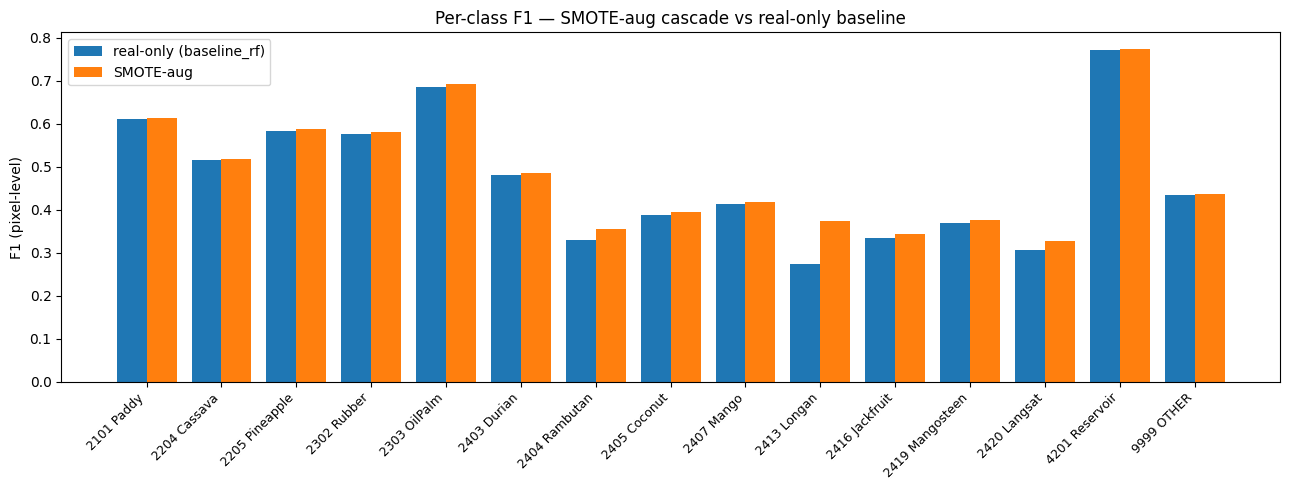

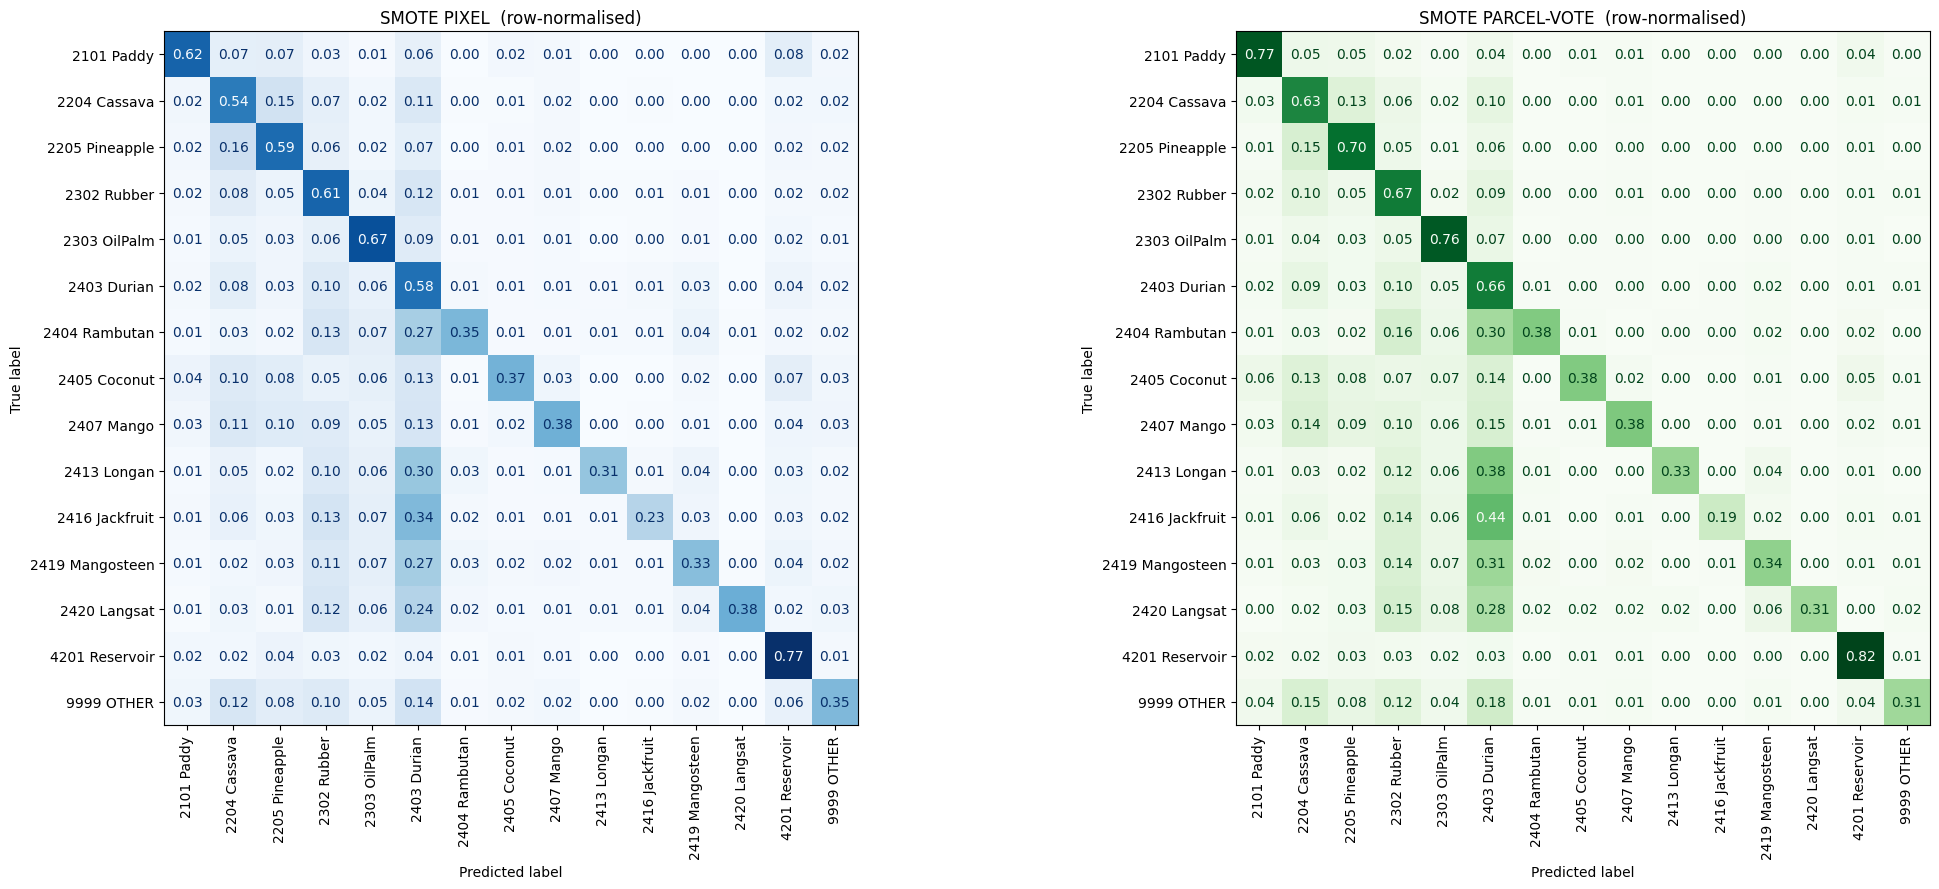

saved -> D:\Github\synth-crop-web\deploy\artifacts\per_class_f1_smote.png
saved -> D:\Github\synth-crop-web\deploy\artifacts\cm_smote_combined.png


In [6]:
# ---- try to load baseline_rf per-class F1 (pixel) for side-by-side ----
BASE_METRICS = ART / 'metrics.json'
f1_real_pix  = None
if BASE_METRICS.exists():
    bm = json.loads(BASE_METRICS.read_text())
    raw = bm.get('pixel_test', {}).get('f1_per_class') or bm.get('metrics', {}).get('f1_per_class')
    if isinstance(raw, list) and len(raw) == len(CLF_CLASSES):
        f1_real_pix = pd.Series(raw, index=CLF_CLASSES, name='real-only')
    elif isinstance(raw, dict):
        f1_real_pix = pd.Series({int(k): v for k, v in raw.items()}, name='real-only').reindex(CLF_CLASSES)

# ---- per-class F1 bar chart ----
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(CLF_CLASSES))
if f1_real_pix is not None:
    ax.bar(x - 0.2, f1_real_pix.to_numpy(), 0.4, label='real-only (baseline_rf)')
    ax.bar(x + 0.2, f1_smote_pix.to_numpy(), 0.4, label='SMOTE-aug')
else:
    ax.bar(x, f1_smote_pix.to_numpy(), 0.6, label='SMOTE-aug')
    print('[note] baseline_rf per-class F1 not in metrics.json — single-bar plot')
ax.set_xticks(x); ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 (pixel-level)')
ax.set_title('Per-class F1 — SMOTE-aug cascade'
             + (' vs real-only baseline' if f1_real_pix is not None else ''))
ax.legend()
plt.tight_layout()
plt.savefig(ART / 'per_class_f1_smote.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- confusion matrices: pixel + parcel ----
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, title, y_t, y_p, cmap in [
    (axes[0], 'SMOTE PIXEL',       y_te, yp_te,   'Blues'),
    (axes[1], 'SMOTE PARCEL-VOTE', py_te, ypp_te, 'Greens'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_t, y_p, labels=CLF_CLASSES.tolist(),
        display_labels=display_labels,
        normalize='true', cmap=cmap, ax=ax, colorbar=False,
        xticks_rotation=90, values_format='.2f',
    )
    ax.set_title(f'{title}  (row-normalised)', fontsize=12)
plt.tight_layout()
plt.savefig(ART / 'cm_smote_combined.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'saved -> {ART/"per_class_f1_smote.png"}')
print(f'saved -> {ART/"cm_smote_combined.png"}')

## 7. Write web artifacts to `deploy/artifacts/`

In [ ]:
# ---- joblib (full SMOTE cascade -> side dir, NOT deploy/artifacts) ----
joblib.dump({
    'clf_s1': clf_s1, 'clf_s2': clf_s2,
    'feature_cols': ALL_FEATS, 'label_names': LABEL_NAMES,
    'tropical_orchards': TROPICAL_ORCHARDS,
    'rf_params': RF_PARAMS, 'rf_params_s2': RF_PARAMS_ORCH,
    'training': 'real_plus_smote_minorities_cascade',
    'smote_target': SMOTE_TARGET, 'minority_classes': minority,
    'k_neighbors': K_NEIGHBORS,
}, JOBLIB_DIR / 'rf_smote_baseline.joblib', compress=3)

# ---- 1. metrics_smote.json ----
metrics_smote = {
    'model_label':       'Random Forest 2-stage cascade + SMOTE minority augmentation',
    'cascade_stages':    'stage-1 base RF (15 cls) + stage-2 tropical-orchard specialist (8 cls)',
    'rf_params':         RF_PARAMS,
    'rf_params_s2':      RF_PARAMS_ORCH,
    'tropical_orchards': TROPICAL_ORCHARDS.tolist(),
    'minority_classes':  minority,
    'smote_target_per_class': SMOTE_TARGET,
    'smote_k_neighbors': K_NEIGHBORS,
    'feature_cols':      ALL_FEATS,
    'classes':           CLF_CLASSES.tolist(),
    'label_names':       {str(int(c)): LABEL_NAMES.get(int(c), '?') for c in CLF_CLASSES},
    'pixel_test': {
        'acc':         float(acc_pix),
        'kappa':       float(kap_pix),
        'f1_weighted': float(f1_w_pix),
        'f1_macro':    float(f1_m_pix),
        'f1_per_class': [float(v) for v in f1_pix],
    },
    'parcel_test': {
        'n_parcels':   int(len(py_te)),
        'acc':         float(acc_par),
        'kappa':       float(kap_par),
        'f1_weighted': float(f1_w_par),
        'f1_macro':    float(f1_m_par),
    },
}
(ART / 'metrics_smote.json').write_text(json.dumps(metrics_smote, indent=2, ensure_ascii=False))

# ---- 2. per-class F1 CSV (SMOTE only; compare against baseline added in next cell) ----
pd.DataFrame({'class': display_labels, 'f1_smote_pixel': f1_smote_pix.to_numpy()}) \
  .to_csv(ART / 'summary_smote_vs_real.csv', index=False, encoding='utf-8')

# ---- 3. synth_smote.parquet (synthetic train rows for Synth Lab page) ----
synth_df = pd.DataFrame(X_syn, columns=ALL_FEATS)
synth_df['label'] = y_syn.astype(np.int32)
synth_df.to_parquet(ART / 'synth_smote.parquet', index=False)

# ---- 4. corr_smote.npy (feature x feature correlation on synthetic rows) ----
np.save(ART / 'corr_smote.npy', np.corrcoef(X_syn, rowvar=False).astype(np.float32))

# ---- 5. confusion_smote.npy (raw counts, pixel) ----
np.save(ART / 'confusion_smote.npy',
        confusion_matrix(y_te, yp_te, labels=CLF_CLASSES.tolist()))

# ---- 6. feature_importance_smote.parquet (stage-1) ----
pd.DataFrame({'feature': ALL_FEATS, 'importance': clf_s1.feature_importances_}) \
  .sort_values('importance', ascending=False) \
  .to_parquet(ART / 'feature_importance_smote.parquet', index=False)

print('--- web artifacts (deploy/artifacts) ---')
for n in ['metrics_smote.json', 'summary_smote_vs_real.csv', 'synth_smote.parquet',
          'corr_smote.npy', 'confusion_smote.npy', 'feature_importance_smote.parquet',
          'per_class_f1_smote.png', 'cm_smote_combined.png']:
    p = ART / n
    if p.exists():
        print(f'  {p.name:<40s} {p.stat().st_size/1e6:>7.2f} MB')

print('\n--- joblibs (side dir) ---')
for p in sorted(JOBLIB_DIR.glob('*.joblib')):
    print(f'  {p.name:<40s} {p.stat().st_size/1e6:>7.2f} MB')

## 8. Three-way compare — baseline_rf vs SMOTE vs TabSyn (read from disk)

In [ ]:
def _flat(name, pix, par):
    pix = pix or {}; par = par or {}
    return {
        'method':             name,
        'pixel_acc':          pix.get('acc') or pix.get('accuracy'),
        'pixel_kappa':        pix.get('kappa'),
        'pixel_f1_weighted':  pix.get('f1_weighted'),
        'pixel_f1_macro':     pix.get('f1_macro'),
        'parcel_acc':         par.get('acc'),
        'parcel_kappa':       par.get('kappa'),
        'parcel_f1_weighted': par.get('f1_weighted'),
        'parcel_f1_macro':    par.get('f1_macro'),
    }

rows = [_flat('SMOTE-aug RF', metrics_smote['pixel_test'], metrics_smote['parcel_test'])]

# ---- baseline_rf ----
if BASE_METRICS.exists():
    bm = json.loads(BASE_METRICS.read_text())
    rows.append(_flat('baseline_rf (real-only)',
                      bm.get('pixel_test', bm.get('metrics')),
                      bm.get('parcel_test')))
else:
    print(f'[skip] baseline_rf metrics not found: {BASE_METRICS}')

# ---- TabSyn (if present) ----
TABSYN_METRICS = ART / 'tabsyn_metrics.json'
if TABSYN_METRICS.exists():
    tm = json.loads(TABSYN_METRICS.read_text())
    rows.append(_flat('TabSyn-aug RF',
                      tm.get('pixel_test', tm.get('augmented_cascade')),
                      tm.get('parcel_test')))
else:
    print(f'[skip] TabSyn metrics not found: {TABSYN_METRICS}')

compare_df = pd.DataFrame(rows).set_index('method')
print('\n=== three-way comparison (test split) ===')
print(compare_df.round(4).to_string())
compare_df.to_csv(ART / 'three_way_compare.csv')
print(f'\nsaved -> {ART/"three_way_compare.csv"}')